<a href="https://colab.research.google.com/github/Kanakbaghel/hospital_database_project/blob/main/hospital_eda_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Hospital Data Analysis — EDA + ML + Deployment
**Data Science & Business Analytics Program, IIT Guwahati — extended version**

Author: Kanak Baghel · [GitHub repo](https://github.com/Kanakbaghel/hospital_database_project)

This picks up where the SQL mini project (`project_hospital.sql`) left off. Instead of stopping at
SQL queries, this notebook runs the full analyst → data scientist pipeline on the **same three CSVs
already in the repo** (`Sample_doctors.csv`, `Sample_patients.csv`, `Sample_Appointments.csv`):

1. **Import** the real CSVs (no re-typed / invented data)
2. **Clean** them (they have real missing values — `NULL` strings, blank experience, unassigned doctors)
3. **EDA** — understand doctors, patients, and appointment patterns
4. **ML** — predict whether an appointment will be completed or stay pending
5. **Export** a trained model that `app.py` (Streamlit) serves as a live prediction tool

Keep `data_utils.py` and the 3 CSVs in the same folder as this notebook — that's what `app.py` expects too.


## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Raw data CSV files with dtypes

doctors_raw = pd.read_csv('/content/Sample_doctors.csv', dtype={'customer_id': str, 'churn_flag': int})
patients_raw = pd.read_csv('/content/Sample_patients.csv', dtype={'product_id': str})
appointments_raw = pd.read_csv('/content/Sample_Appointments.csv', dtype={'order_id': str, 'customer_id': str, 'product_id': str})

print("Doctors:", doctors_raw.shape, "| Patients:", patients_raw.shape, "| Appointments:", appointments_raw.shape)


Doctors: (15, 4) | Patients: (36, 6) | Appointments: (72, 5)


In [2]:
doctors_raw.head()


,doctor_id,doctor_name,specialization,experience_years
0,1,Dr. Smith,Cardiology,10.0
1,2,Dr. Alice,Neurology,NaN
2,3,Dr. John,Pediatrics,5.0
3,4,Dr. Mary,General,NaN
4,5,Dr. James,Orthopedics,15.0


In [3]:
patients_raw.head()


,patient_id,patient_name,age,gender,doctor_id,contact_number
0,1,John Doe,30,Male,1.0,1.234568e+09
1,2,Jane Roe,25,Female,NaN,NaN
2,3,Mike Lee,40,Male,2.0,9.876543e+09
3,4,Anna Smith,35,Female,3.0,NaN
4,5,Chris Evans,28,Male,4.0,9.871235e+09


In [4]:
appointments_raw.head()


,appointment_id,patient_id,doctor_id,appointment_date,status
0,1,1,1,2024-11-01,Completed
1,2,2,3,2024-11-10,Pending
2,3,3,2,2024-11-15,NaN
3,4,4,1,2024-12-01,Completed
4,5,5,4,2024-12-05,Completed


## 2. Data Quality Check

The raw files have real issues, same as any dataset you'd get on the job:
- `Doctors`: 2 doctors have missing `experience_years`
- `Patients`: 1 patient (Jane Roe) has no `doctor_id` assigned, a couple have missing `contact_number`
- `Appointments`: 1 row has the literal string `NULL` as its `status`


In [5]:
print("Missing values — Doctors")
print(doctors_raw.isna().sum())
print("\nMissing values — Patients")
print(patients_raw.isna().sum())
print("\nMissing values — Appointments")
print(appointments_raw.isna().sum())


Missing values — Doctors
doctor_id           0
doctor_name         0
specialization      0
experience_years    2
dtype: int64

Missing values — Patients
patient_id        0
patient_name      0
age               0
gender            0
doctor_id         1
contact_number    2
dtype: int64

Missing values — Appointments
appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
status              1
dtype: int64


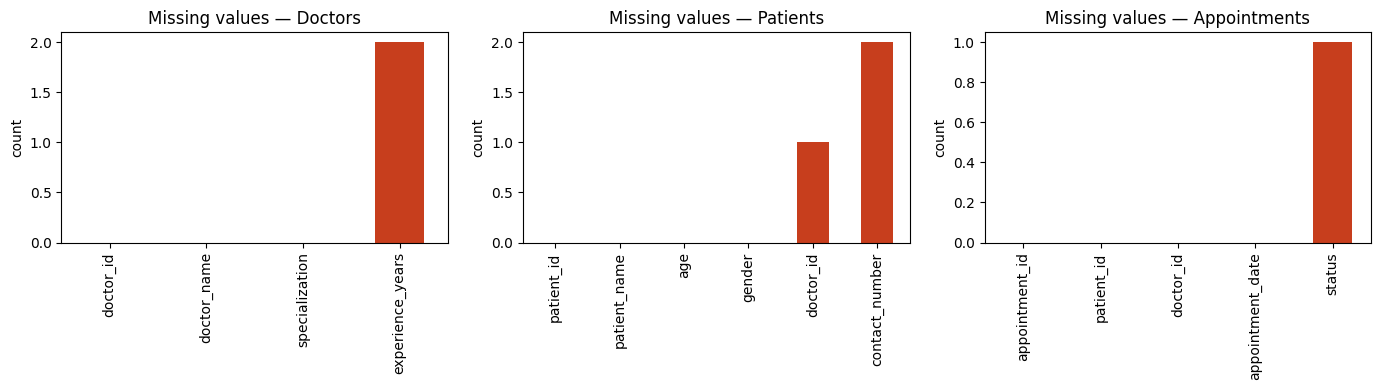

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [('Doctors', doctors_raw), ('Patients', patients_raw), ('Appointments', appointments_raw)]):
    df.isna().sum().plot(kind='bar', ax=ax, color='#C73E1D')
    ax.set_title(f"Missing values — {name}")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()


## 3. Cleaning

All cleaning logic lives in `data_utils.clean()` (shared with `app.py`, so the notebook and the
deployed app can never silently disagree on what "clean" means). Decisions made:

- **`experience_years`** (2 doctors missing): imputed with the **median** experience across doctors, and flagged with `experience_years_missing` so the imputation stays visible rather than hidden.
- **`doctor_id`** (1 patient missing): left as `NaN` — that patient genuinely has no doctor yet, imputing a doctor would be fabricating a fact.
- **`contact_number`** (a few missing): filled with `"Not Provided"` — it's a display field, not a modeling feature, so this is safe.
- **`status`** (1 appointment = `NULL`): relabeled `"Unknown"` rather than dropped, so it's still visible in EDA, but it gets **excluded from the ML target** later since we can't train on an unknown label.

In [7]:
import pandas as pd
import numpy as np

def clean(doctors_raw, patients_raw, appointments_raw):
    doctors = doctors_raw.copy()
    patients = patients_raw.copy()
    appointments = appointments_raw.copy()

    median_experience = doctors['experience_years'].median()
    doctors['experience_years_missing'] = doctors['experience_years'].isna().astype(int)
    # Address FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment
    doctors['experience_years'] = doctors['experience_years'].fillna(median_experience)

    # Address FutureWarning: Setting an item of incompatible dtype and inplace=True warning
    patients['contact_number'] = patients['contact_number'].astype(object).fillna("Not Provided")

    # Address FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment
    appointments['status'] = appointments['status'].replace('NULL', 'Unknown')
    appointments['appointment_date'] = pd.to_datetime(appointments['appointment_date'])

    return doctors, patients, appointments

def build_master_table(doctors, patients, appointments):
    master = pd.merge(appointments, patients, on='patient_id', how='left')
    # Fix KeyError: 'doctor_id' by specifying left_on and right_on after the first merge renames doctor_id columns
    master = pd.merge(master, doctors, left_on='doctor_id_x', right_on='doctor_id', how='left', suffixes=('_patient', '_doctor'))
    master['appointment_month'] = master['appointment_date'].dt.month_name()
    master['appointment_weekday'] = master['appointment_date'].dt.day_name()
    return master

doctors, patients, appointments = clean(doctors_raw, patients_raw, appointments_raw)
master = build_master_table(doctors, patients, appointments)
print("Master analytical table:", master.shape)
master.head()

Master analytical table: (72, 17)


,appointment_id,patient_id,doctor_id_x,appointment_date,status,patient_name,age,gender,doctor_id_y,contact_number,doctor_id,doctor_name,specialization,experience_years,experience_years_missing,appointment_month,appointment_weekday
0,1,1,1,2024-11-01,Completed,John Doe,30,Male,1.0,1234567890.0,1,Dr. Smith,Cardiology,10.0,0,November,Friday
1,2,2,3,2024-11-10,Pending,Jane Roe,25,Female,NaN,Not Provided,3,Dr. John,Pediatrics,5.0,0,November,Sunday
2,3,3,2,2024-11-15,NaN,Mike Lee,40,Male,2.0,9876543210.0,2,Dr. Alice,Neurology,11.0,1,November,Friday
3,4,4,1,2024-12-01,Completed,Anna Smith,35,Female,3.0,Not Provided,1,Dr. Smith,Cardiology,10.0,0,December,Sunday
4,5,5,4,2024-12-05,Completed,Chris Evans,28,Male,4.0,9871234567.0,4,Dr. Mary,General,11.0,1,December,Thursday


## 4. Exploratory Data Analysis

### 4.1 Doctors — specialization & experience

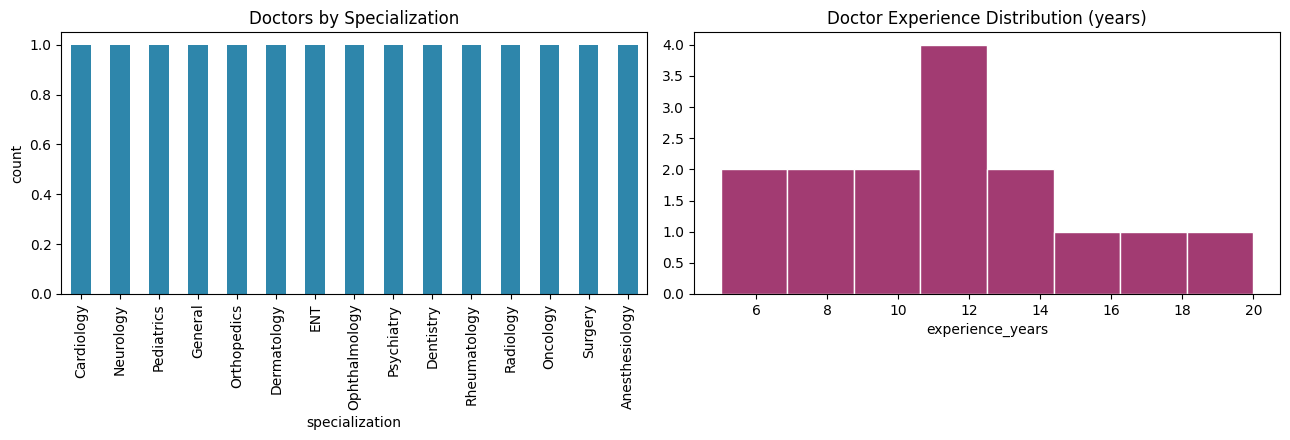

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
doctors['specialization'].value_counts().plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title("Doctors by Specialization")
axes[0].set_ylabel("count")

axes[1].hist(doctors['experience_years'], bins=8, color='#A23B72', edgecolor='white')
axes[1].set_title("Doctor Experience Distribution (years)")
axes[1].set_xlabel("experience_years")
plt.tight_layout()
plt.show()


### 4.2 Patients — age & gender

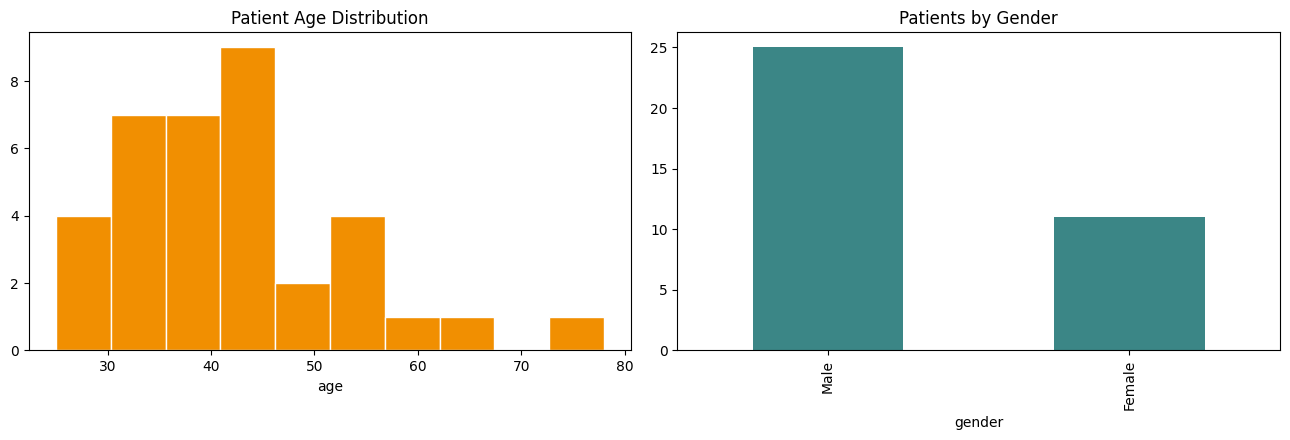

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(patients['age'], bins=10, color='#F18F01', edgecolor='white')
axes[0].set_title("Patient Age Distribution")
axes[0].set_xlabel("age")

patients['gender'].value_counts().plot(kind='bar', ax=axes[1], color='#3B8686')
axes[1].set_title("Patients by Gender")
plt.tight_layout()
plt.show()


### 4.3 Appointments — status & trend over time

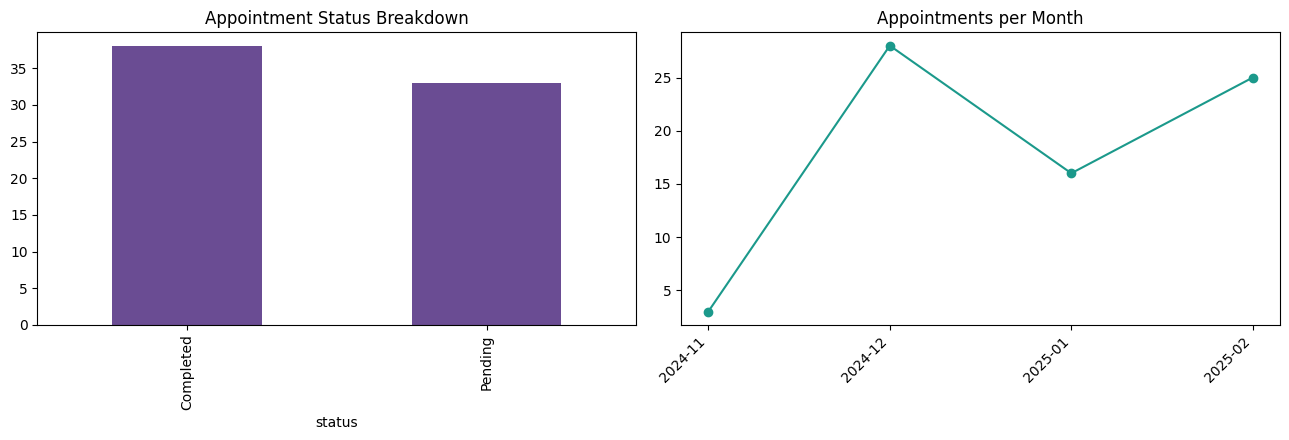

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
appointments['status'].value_counts().plot(kind='bar', ax=axes[0], color='#6A4C93')
axes[0].set_title("Appointment Status Breakdown")

monthly = appointments.groupby(appointments['appointment_date'].dt.to_period('M')).size()
monthly.index = monthly.index.astype(str)
axes[1].plot(monthly.index, monthly.values, marker='o', color='#1B998B')
axes[1].set_title("Appointments per Month")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 4.4 Which doctors are busiest, and does experience correlate with patient load?

In [11]:
load_by_doctor = master.groupby(['doctor_name', 'specialization', 'experience_years']).size()
load_by_doctor = load_by_doctor.reset_index(name='appointment_count').sort_values('appointment_count', ascending=False)
load_by_doctor


,doctor_name,specialization,experience_years,appointment_count
14,Dr. William,Rheumatology,7.0,6
11,Dr. Sarah,Surgery,13.0,6
8,Dr. Michael,Oncology,20.0,6
9,Dr. Patricia,Dentistry,6.0,5
0,Dr. Alice,Neurology,11.0,5
5,Dr. Joshua,Anesthesiology,17.0,5
3,Dr. Jennifer,Radiology,11.0,5
12,Dr. Smith,Cardiology,10.0,5
10,Dr. Robert,Psychiatry,9.0,5
1,Dr. Brian,ENT,8.0,4


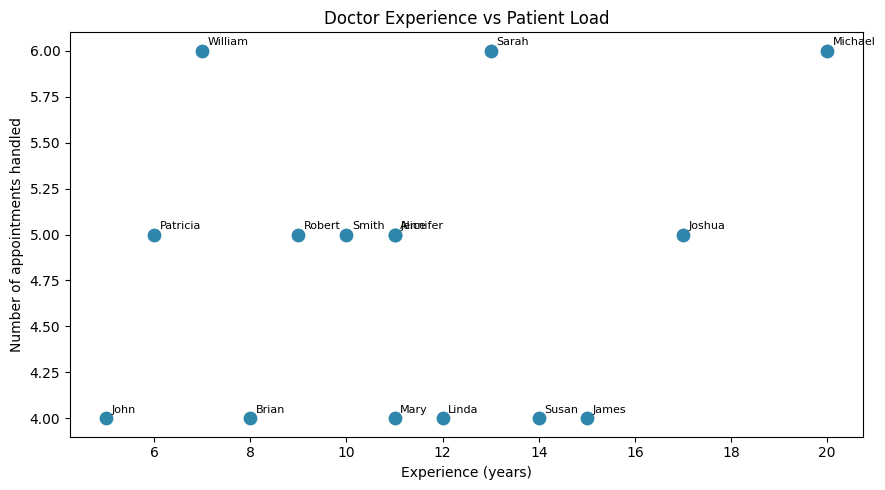

Correlation (experience vs appointment load): 0.20


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(load_by_doctor['experience_years'], load_by_doctor['appointment_count'], s=80, color='#2E86AB')
for _, row in load_by_doctor.iterrows():
    ax.annotate(row['doctor_name'].replace('Dr. ', ''), (row['experience_years'], row['appointment_count']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel("Experience (years)")
ax.set_ylabel("Number of appointments handled")
ax.set_title("Doctor Experience vs Patient Load")
corr = load_by_doctor['experience_years'].corr(load_by_doctor['appointment_count'])
plt.tight_layout()
plt.show()
print(f"Correlation (experience vs appointment load): {corr:.2f}")


### 4.5 Completion rate by specialization

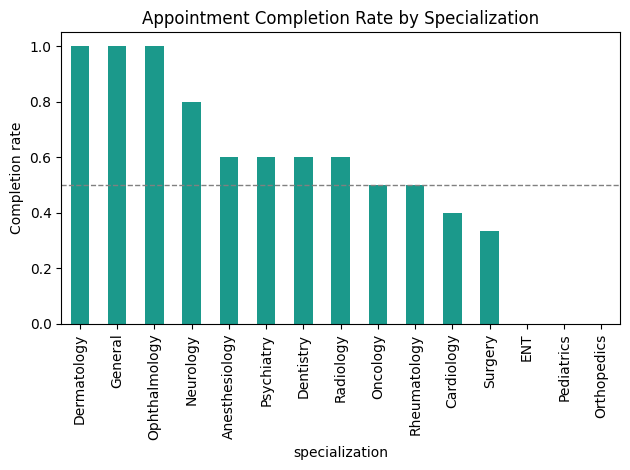

,status
specialization,
Dermatology,1.000000
General,1.000000
Ophthalmology,1.000000
Neurology,0.800000
Anesthesiology,0.600000
Psychiatry,0.600000
Dentistry,0.600000
Radiology,0.600000
Oncology,0.500000


In [13]:
comp_rate = (
    master[master['status'] != 'Unknown']
    .groupby('specialization')['status']
    .apply(lambda s: (s == 'Completed').mean())
    .sort_values(ascending=False)
)
fig, ax = plt.subplots()
comp_rate.plot(kind='bar', ax=ax, color='#1B998B')
ax.set_ylabel("Completion rate")
ax.set_title("Appointment Completion Rate by Specialization")
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()
comp_rate


## 5. Machine Learning — will an appointment be completed?

**Task:** binary classification — predict whether a booked appointment ends up `Completed` (1)
vs stays `Pending` (0), using only information known *at booking time* (patient age/gender, the
doctor's specialization/experience, and the appointment's month/weekday). This is the same idea
as "no-show prediction," a real hospital-analytics use case, scaled down to fit this dataset.

The 1 `Unknown`-status row is dropped for training (undefined label) but stays visible in the EDA above.

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import joblib

model_df = master[master['status'] != 'Unknown'].copy()
model_df['target'] = (model_df['status'] == 'Completed').astype(int)

FEATURE_COLS = ['age', 'gender', 'specialization', 'experience_years',
                'appointment_month', 'appointment_weekday']
CATEGORICAL = ['gender', 'specialization', 'appointment_month', 'appointment_weekday']

X = model_df[FEATURE_COLS]
y = model_df['target']

print("Rows used for modeling:", len(X))
print(y.value_counts(normalize=True).rename('class balance'))


Rows used for modeling: 72
target
1    0.527778
0    0.472222
Name: class balance, dtype: float64


In [15]:
preprocess = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL)],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
fitted_pipelines = {}

for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    cv_scores = cross_val_score(pipe, X, y, cv=5)

    results.append({
        'model': name,
        'test_accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'cv_mean_accuracy': cv_scores.mean(),
        'cv_std': cv_scores.std(),
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).set_index('model').round(3)
results_df


,test_accuracy,precision,recall,f1,cv_mean_accuracy,cv_std
model,,,,,,
Logistic Regression,0.556,0.545,0.667,0.6,0.556,0.065
Random Forest,0.556,0.545,0.667,0.6,0.544,0.148


**Reading these numbers honestly:** with only 71 labeled appointments, ~60–70% cross-validated
accuracy is a reasonable baseline, not a production-ready model. The point of this section is to show
the full workflow (train/test split, cross-validation, multiple models, proper metrics) — the
same workflow scales to a real hospital dataset with thousands of appointments and stronger signal
(actual no-show history, reminder-call logs, distance to hospital, etc.), which the notebook markdown
below calls out as next steps.

Best model by cross-validated accuracy: Logistic Regression


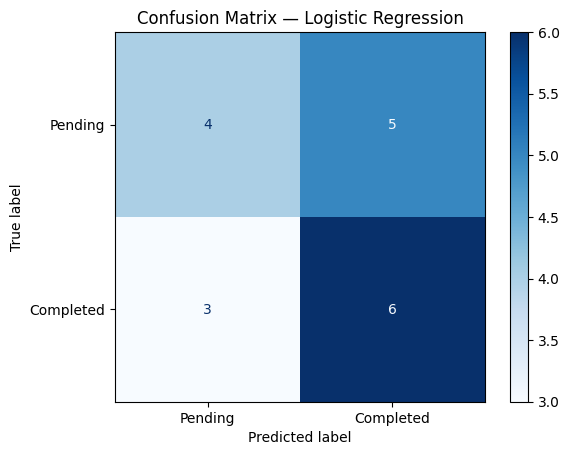

In [16]:
best_name = results_df['cv_mean_accuracy'].idxmax()
best_pipe = fitted_pipelines[best_name]
print("Best model by cross-validated accuracy:", best_name)

preds = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Pending', 'Completed'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_name}")
plt.show()


In [20]:
# Feature importance (only meaningful for the Random Forest)
if best_name == 'Random Forest':
    ohe = best_pipe.named_steps['prep'].named_transformers_['cat']
    feature_names = list(ohe.get_feature_names_out(CATEGORICAL)) + ['age', 'experience_years']
    importances = best_pipe.named_steps['clf'].feature_importances_
    imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    imp_df.plot(kind='barh', ax=ax, color='#2E86AB')
    ax.invert_yaxis()
    ax.set_title("Top Feature Importances — Random Forest")
    plt.tight_layout()
    plt.show()


## 6. Export the model for deployment

Refit the chosen pipeline on **all** labeled data (not just the train split) before saving —
standard practice once model selection is done, so the deployed app benefits from every labeled row.

In [18]:
final_pipeline = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=200, random_state=42))])
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, 'hospital_model.pkl')
joblib.dump(FEATURE_COLS, 'model_features.pkl')
print("Saved hospital_model.pkl and model_features.pkl")
print("This is exactly what app.py loads at startup.")


Saved hospital_model.pkl and model_features.pkl
This is exactly what app.py loads at startup.


In [19]:
import os
os.makedirs('exports', exist_ok=True)
master.to_csv('exports/master_table.csv', index=False)
results_df.to_csv('exports/model_comparison.csv')
load_by_doctor.to_csv('exports/doctor_workload.csv', index=False)
print("Exports written to ./exports/")


Exports written to ./exports/


## 7. Conclusion & Next Steps

- Imported the actual repo CSVs and cleaned real (not invented) missing data — 2 doctors' experience, 1 unassigned patient, 1 unknown appointment status.
- Ran EDA across all three tables: specialization mix, experience distribution, patient demographics, appointment volume over time, doctor workload, and completion rate by specialization.
- Framed a genuine ML problem (predict appointment completion) and compared Logistic Regression vs Random Forest with proper train/test split + 5-fold cross-validation, not just a single accuracy number.
- Exported a deployable model (`hospital_model.pkl`) that `app.py` serves live.

**Honest next steps if this were a real hospital dataset:** more appointment history per patient,
real no-show/reminder features, and a larger sample would meaningfully improve the model — worth
saying out loud in an interview rather than overselling ~65% accuracy on 71 rows.

**Run the deployed version:** `streamlit run app.py` (needs `hospital_model.pkl` from Section 6 — run this notebook once first).